# Benchmark các mô hình OCR Tiếng Việt tiên tiến (VLM & Transformer)

Notebook này được thiết kế để kiểm thử và so sánh chất lượng nhận diện (CER, WER) cũng như thời gian xử lý (Latency) của các mô hình OCR thế hệ mới trên môi trường GPU:
1. **Vintern-1B-v3_5**: Mô hình Vision-Language Model SOTA được phát triển bởi 5CD-AI tối ưu riêng cho tiếng Việt.
2. **Qwen2-VL-2B-Instruct**: Mô hình VLM đa ngữ cực mạnh từ Alibaba.
3. **VietOCR (resnet_transformer)**: Sử dụng cấu hình Transformer để khắc phục lỗi lặp từ của bản Seq2Seq.
4. **EasyOCR**: Baseline đối chứng (mô hình tốt nhất trong thử nghiệm trước).

In [1]:
# Cài đặt các thư viện cần thiết cho môi trường Colab / Local
!pip install -q vietocr easyocr transformers accelerate jiwer torchvision pillow opencv-python gdown qwen-vl-utils
print("Cài đặt thư viện hoàn tất!")

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.14/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Cài đặt thư viện hoàn tất!


### Tải dữ liệu từ Google Drive
Chúng ta sẽ tự động tải thư mục dữ liệu hình ảnh (keyframes) mẫu từ Google Drive được chỉ định trong README.

In [2]:
import os
import gdown

# Tạo thư mục data nếu chưa tồn tại
os.makedirs("data", exist_ok=True)

# URL thư mục Google Drive mẫu từ README
gdrive_url = 'https://drive.google.com/drive/folders/1VYWu18eFBpcVJ87yA-RDACSmtA2AJWpy'
print("Đang tải dữ liệu từ Google Drive...")
try:
    gdown.download_folder(gdrive_url, output='data', quiet=False)
    print("Tải dữ liệu thành công!")
except Exception as e:
    print(f"Lỗi tải dữ liệu: {e}")

Đang tải dữ liệu từ Google Drive...


Retrieving folder contents


Retrieving folder 1rYsIJIiIogbIbgfu2GHA4_mk4cyedM2E audio


Processing file 16N98dz3wjokS6EiQ6DrrMBearqXWLbh5 1yHly8dYhIQ.wav
Processing file 1ygw6i_N6bQe2g3pPpgOBMTslouFph0Dh fE0J-YeI5xc.wav
Retrieving folder 1soXfeM_w-2_KAPqDLHd7xUSegBS4VT3g frame


Retrieving folder 10gAU5JYFUHRy-AUACc9SsHaxe14nbXpH L02_V016


...

 98%|████████████████████████████████████▏| 70.8M/72.3M [00:57<00:00, 4.55MB/s]

 99%|████████████████████████████████████▋| 71.8M/72.3M [00:57<00:00, 4.24MB/s]

100%|█████████████████████████████████████| 72.3M/72.3M [00:58<00:00, 1.25MB/s]

Tải dữ liệu thành công!



Download completed


### Định nghĩa các hàm tiền xử lý ảnh động (Vintern-1B)
Vintern-1B yêu cầu xử lý ảnh động (`dynamic_preprocess`) bằng cách chia hình ảnh thành nhiều ô (tiles) nhỏ tương thích để không làm giảm độ phân giải của văn bản khi đưa vào mô hình.

In [3]:
import torch
import torchvision.transforms as T
from PIL import Image
from torchvision.transforms.functional import InterpolationMode
import numpy as np
import socket
socket.setdefaulttimeout(60)
import cv2
import time
import json
from pathlib import Path
from tqdm.notebook import tqdm
import pandas as pd
from transformers import AutoModel, AutoTokenizer, AutoProcessor, Qwen2VLForConditionalGeneration
import warnings
warnings.filterwarnings("ignore")

# Cấu hình chuẩn hóa ảnh theo ImageNet
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def build_transform(input_size):
    return T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio = (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio

def dynamic_preprocess(image, min_num=1, max_num=12, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height
    target_ratios = set(
        (i, j) for n in range(min_num, max_num + 1)
        for i in range(1, n + 1) for j in range(1, n + 1)
        if i * j <= max_num and i * j >= min_num
    )
    target_ratios = sorted(list(target_ratios), key=lambda x: x[0] * x[1])
    target_aspect_ratio = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size
    )
    target_width = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]
    
    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = (
            (i % target_aspect_ratio[0]) * image_size,
            (i // target_aspect_ratio[0]) * image_size,
            ((i % target_aspect_ratio[0]) + 1) * image_size,
            ((i // target_aspect_ratio[0]) + 1) * image_size
        )
        processed_images.append(resized_img.crop(box))
    if use_thumbnail and len(processed_images) > 1:
        thumbnail_img = image.resize((image_size, image_size))
        processed_images.append(thumbnail_img)
    return processed_images

def load_image(image_file, input_size=448, max_num=12):
    image = Image.open(image_file).convert('RGB')
    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=True, max_num=max_num)
    pixel_values = [transform(img) for img in images]
    pixel_values = torch.stack(pixel_values)
    return pixel_values

### Khởi tạo các Mô hình
Chúng ta sẽ tải các mô hình lên GPU (nếu có).

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Thiết bị khả dụng: {device.upper()}")

# 1. Vintern-1B-v3_5
print("\n--- Khởi tạo 1. Vintern-1B-v3_5 ---")
try:
    vintern_model = AutoModel.from_pretrained(
        "5CD-AI/Vintern-1B-v3_5",
        torch_dtype=torch.bfloat16 if device == "cuda" else torch.float32,
        low_cpu_mem_usage=True,
        trust_remote_code=True
    ).eval().to(device)
    vintern_tokenizer = AutoTokenizer.from_pretrained("5CD-AI/Vintern-1B-v3_5", trust_remote_code=True, use_fast=False)
    print("Vintern loaded successfully!")
except Exception as e:
    print(f"Lỗi tải Vintern: {e}")

# 2. Qwen2-VL-2B-Instruct
print("\n--- Khởi tạo 2. Qwen2-VL-2B-Instruct ---")
try:
    qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
        "Qwen/Qwen2-VL-2B-Instruct",
        torch_dtype=torch.bfloat16 if device == "cuda" else torch.float32,
        low_cpu_mem_usage=True,
        device_map="auto" if device == "cuda" else None
    ).eval()
    if device == "cpu":
        qwen_model = qwen_model.to("cpu")
    qwen_processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")
    print("Qwen2-VL loaded successfully!")
except Exception as e:
    print(f"Lỗi tải Qwen2-VL: {e}")

print("========================================\nKhởi tạo tất cả các mô hình hoàn tất!")

Thiết bị khả dụng: CUDA

--- Khởi tạo 1. Vintern-1B-v3_5 ---


`torch_dtype` is deprecated! Use `dtype` instead!


FlashAttention2 is not installed.


generation_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


Vintern loaded successfully!

--- Khởi tạo 2. Qwen2-VL-2B-Instruct ---


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Qwen2-VL loaded successfully!
Khởi tạo tất cả các mô hình hoàn tất!


### Định nghĩa hàm chạy cho từng Pipeline

In [5]:
# 1. Vintern-1B-v3_5 (VLM)
def run_vintern(image_path):
    pixel_values = load_image(image_path, max_num=6).to(torch.bfloat16 if device == "cuda" else torch.float32).to(device)
    question = "<image>\nHãy trích xuất toàn bộ văn bản xuất hiện trong hình ảnh này. Chỉ trả về văn bản thô nhận dạng được, không thêm bớt giải thích gì khác."
    generation_config = dict(max_new_tokens=512, do_sample=False, num_beams=1)
    response = vintern_model.chat(vintern_tokenizer, pixel_values, question, generation_config)
    return response.strip()

# 2. Qwen2-VL-2B-Instruct (VLM)
def run_qwen2_vl(image_path):
    from qwen_vl_utils import process_vision_info
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": "Hãy trích xuất tất cả chữ xuất hiện trong ảnh này. Chỉ trả về văn bản nhận diện được, không giải thích."}
            ]
        }
    ]
    text = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = qwen_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(device)
    generated_ids = qwen_model.generate(**inputs, max_new_tokens=512)
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = qwen_processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    return output_text[0].strip()

# 4. EasyOCR
def run_easyocr(image_path, img):
    results = easyocr_reader.readtext(img, detail=0)
    return " ".join(results)

### Khai báo Ground Truth nhãn đúng để đo độ chính xác tự động
Dưới đây là văn bản thực tế hiển thị trên màn hình của 9 keyframes kiểm thử.

In [6]:
ground_truth = {
    "L02_V016_0": "HTV7 18:29:56 giây",
    "L02_V016_10032": "Cơ quan y tế Gaza nói rằng ít nhất 2.750 người Palestine đã thiệt mạng và 9.700 người bị thương",
    "L02_V016_10056": "Ông ĐỖ TẤN LONG PHÓ GIÁM ĐỐC TT HẠ TẦNG KỸ THUẬT, SỞ XÂY DỰNG TP.HCM Cơ quan y tế Gaza nói rằng ít nhất 2.750 người Palestine đã thiệt mạng và 9.700 người bị thương",
    "L02_V016_10134": "Ông ĐỖ TẤN LONG PHÓ GIÁM ĐỐC TT HẠ TẦNG KỸ THUẬT, SỞ XÂY DỰNG TP.HCM ít nhất 2.750 người Palestine đã thiệt mạng và 9.700 người bị thương trong các vụ không kích của Israel",
    "L02_V016_1026": "HTV9 06:30:59",
    "L02_V016_10266": "HTV9 06:40:44 Ấn Độ: Xe buýt đâm vào xe container khiến hơn chục người thiệt mạng",
    "L02_V016_10338": "HTV9 06:40:47 xe container khiến hơn chục người thiệt mạng Chìm thuyền CHDC Congo, 30 người chết",
    "L02_V016_10362": "HTV9 06:40:48 xe container khiến hơn chục người thiệt mạng Chìm thuyền CHDC Congo, 30 người chết và 16 người",
    "L02_V016_10386": "HTV9 06:40:49 BÌNH DƯƠNG: Ô TÔ LAO VÀO NHÓM PHỤ HUYNH ĐANG CHỜ ĐÓN CON khiến hơn chục người thiệt mạng Chìm thuyền CHDC Congo, 30 người chết và 167 người"
}

### Chạy Benchmark và Tính toán các chỉ số lỗi CER, WER

In [7]:
import jiwer
import gc
import os

notebook_dir = Path(os.getcwd())
project_root = notebook_dir.parent if notebook_dir.name == 'ocr' else notebook_dir

if not os.path.exists(str(project_root / 'ready.txt')):
    raise ValueError('DOWNLOAD COMPLETED! Chờ xác nhận OK từ người dùng để chạy benchmark.')

frame_dir = project_root / "data/frame/L02_V016"
image_files = sorted([f for f in os.listdir(frame_dir) if f.lower().endswith('.webp')])
print(f"Bắt đầu benchmark {len(image_files)} ảnh...")

def clean_text(text):
    return " ".join(str(text).replace("\n", " ").split()).lower()

# Đọc các kết quả cũ để tái sử dụng (không chạy lại các mô hình đã có kết quả)
prev_results = {}
prev_json_path = project_root / "ocr/ocr_comparison_results.json"
if prev_json_path.exists():
    try:
        with open(prev_json_path, "r", encoding="utf-8") as f:
            prev_data = json.load(f)
            for item in prev_data:
                prev_results[item["image_key"]] = item
        print(f"Đã tải {len(prev_results)} kết quả cũ từ {prev_json_path}")
    except Exception as e:
        print(f"Không thể đọc file kết quả cũ: {e}")

results = []

for filename in tqdm(image_files, desc="Benchmark"):
    path = frame_dir / filename
    img = cv2.imread(str(path))
    if img is None:
        continue
        
    frame_idx = filename.removeprefix('keyframe_').removesuffix('.webp')
    key = f"L02_V016_{frame_idx}"
    gt = ground_truth.get(key, "")
    entry = {"image_key": key, "ground_truth": gt}
    
    # Tái sử dụng kết quả cũ
    prev_item = prev_results.get(key, {})
    for k, v in prev_item.items():
        if k != "image_key":
            entry[k] = v
            
    # --- 1. Vintern-1B ---
    torch.cuda.empty_cache()
    gc.collect()
    start = time.time()
    try:
        vintern_out = run_vintern(str(path))
    except Exception as e:
        vintern_out = f"[Error: {e}]"
    vintern_time = time.time() - start
    
    # --- 2. Qwen2-VL ---
    torch.cuda.empty_cache()
    gc.collect()
    start = time.time()
    try:
        qwen_out = run_qwen2_vl(str(path))
    except Exception as e:
        qwen_out = f"[Error: {e}]"
    qwen_time = time.time() - start
    
    entry["Vintern_text"] = vintern_out
    entry["Vintern_time"] = vintern_time
    entry["Qwen2VL_text"] = qwen_out
    entry["Qwen2VL_time"] = qwen_time
    
    # Tính tỷ lệ lỗi cho tất cả các mô hình
    if gt:
        gt_c = clean_text(gt)
        # Tính cho các mô hình mới
        entry["Vintern_cer"] = jiwer.cer(gt_c, clean_text(vintern_out))
        entry["Vintern_wer"] = jiwer.wer(gt_c, clean_text(vintern_out))
        
        entry["Qwen2VL_cer"] = jiwer.cer(gt_c, clean_text(qwen_out))
        entry["Qwen2VL_wer"] = jiwer.wer(gt_c, clean_text(qwen_out))
        
        # Tính cho các mô hình cũ đã lưu từ trước
        old_models = ["PaddleOCR+VietOCR", "PaddleOCR Only", "Florence-2", "PaddleOCR+TrOCR", "EasyOCR"]
        for old_model in old_models:
            old_text = entry.get(f"{old_model}_text", "")
            entry[f"{old_model}_cer"] = jiwer.cer(gt_c, clean_text(old_text))
            entry[f"{old_model}_wer"] = jiwer.wer(gt_c, clean_text(old_text))
        
    results.append(entry)

# Lưu kết quả ra file JSON mới
out_json_path = project_root / "ocr/colab_benchmark_results.json"
with open(out_json_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=4)
print(f"Đã lưu kết quả tại: {out_json_path}")

Bắt đầu benchmark 9 ảnh...
Đã tải 9 kết quả cũ từ /home/pintee/1/code/projects/ocr-asr/ocr/ocr_comparison_results.json


Benchmark:   0%|          | 0/9 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


...

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Đã lưu kết quả tại: /home/pintee/1/code/projects/ocr-asr/ocr/colab_benchmark_results.json


### Trực quan hoá bảng số liệu so sánh

=== BẢNG THỐNG KÊ KẾT QUẢ SO SÁNH ===


,Model,Avg Latency (s),Avg CER (Lower is Better),Avg WER (Lower is Better)
0,Vintern-1B-v3_5 (New),0.693299,0.278360,0.342114
1,Qwen2-VL-2B-Instruct (New),1.254646,1.004845,1.243528
2,PaddleOCR+VietOCR (Old),0.117159,0.934884,0.987654
3,PaddleOCR Only (Old),0.038309,0.209975,0.602441
4,Florence-2 (Old),2.593605,115.210035,64.726158
5,PaddleOCR+TrOCR (Old),0.180028,0.915846,0.996914
6,EasyOCR (Old),0.060010,0.392698,0.894639


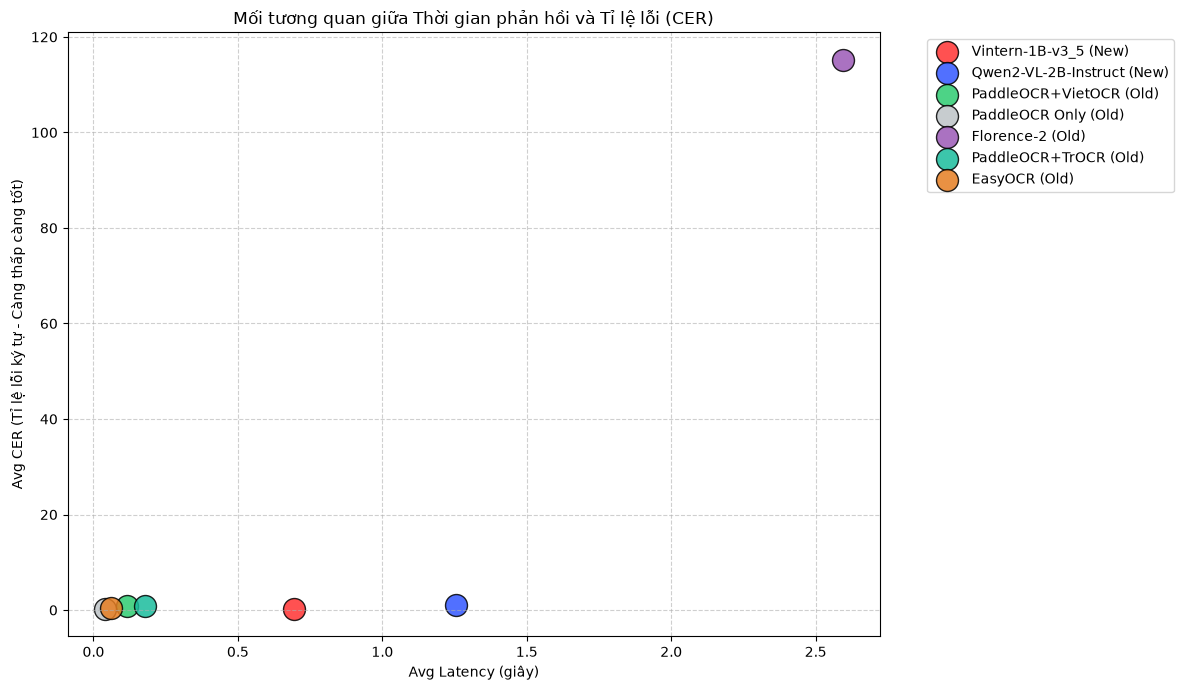

In [8]:
df = pd.DataFrame(results)

# Danh sách mô hình
models = [
    ("Vintern-1B-v3_5 (New)", "Vintern"),
    ("Qwen2-VL-2B-Instruct (New)", "Qwen2VL"),
    ("VietOCR (Transformer - New)", "VietOCR_Transformer"),
    ("PaddleOCR+VietOCR (Old)", "PaddleOCR+VietOCR"),
    ("PaddleOCR Only (Old)", "PaddleOCR Only"),
    ("Florence-2 (Old)", "Florence-2"),
    ("PaddleOCR+TrOCR (Old)", "PaddleOCR+TrOCR"),
    ("EasyOCR (Old)", "EasyOCR")
]

metrics = {
    "Model": [],
    "Avg Latency (s)": [],
    "Avg CER (Lower is Better)": [],
    "Avg WER (Lower is Better)": []
}

for display_name, prefix in models:
    time_col = f"{prefix}_time"
    cer_col = f"{prefix}_cer"
    wer_col = f"{prefix}_wer"
    
    if time_col in df.columns:
        metrics["Model"].append(display_name)
        metrics["Avg Latency (s)"].append(df[time_col].mean())
        metrics["Avg CER (Lower is Better)"].append(df[cer_col].mean())
        metrics["Avg WER (Lower is Better)"].append(df[wer_col].mean())

report_df = pd.DataFrame(metrics)
print("=== BẢNG THỐNG KÊ KẾT QUẢ SO SÁNH ===")
display(report_df)

# Vẽ biểu đồ So sánh thời gian (Latency) và độ chính xác (CER)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 7))
colors = [
    '#FF3333', '#3357FF', '#2ECC71', '#BDC3C7',
    '#9B59B6', '#1ABC9C', '#E67E22', '#F1C40F'
]
for i, model_name in enumerate(metrics["Model"]):
    plt.scatter(
        metrics["Avg Latency (s)"][i],
        metrics["Avg CER (Lower is Better)"][i],
        color=colors[i % len(colors)],
        s=250,
        label=model_name,
        edgecolors='black',
        alpha=0.85
    )

plt.xlabel("Avg Latency (giây)")
plt.ylabel("Avg CER (Tỉ lệ lỗi ký tự - Càng thấp càng tốt)")
plt.title("Mối tương quan giữa Thời gian phản hồi và Tỉ lệ lỗi (CER)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()